# 文本分类思路
- 整个代码包括：数据解析加载、模型构建、损失函数构建、优化器构建、迭代训练、模型评估可视化、模型持久化等相关逻辑；
- 数据解析加载：
  * 原始数据格式信息分析：原始数据为磁盘中的文本数据，使用csv格式存储，主要有两个信息：文本数据 -> str  文本对应标签类别名称 -> str;
  * 定义好文本分词/划分Token的方式：词(Word)、字符(Char)、子词(Sub-Word)
    - 第一版中直接采用基于jieba进行原始的分词
  * 构建词典映射mapping以及输出到磁盘
  * 构建标签映射mapping以及输出到磁盘
  * 构建分词器：简化分词、token2id的转换过程 --> 面向对象编程
  * 构建数据加载器DataSet：自定义Dataset，利用构建好的分词器对文本数据进行分词以及token转id的操作；
  * 构建批次数据加载器DataLoader：自定义批次数据合并的方法；
- 模型构建：
  - 模型输入：
      * 批次样本token id列表，shape形状为：\[bs,t], 内部取值就是每个token对应的id；
      * 批次样本token填充信息，shape形状为: \[bs,t], 1表示当前token id为实际值，0表示当前位置的token id是填充值；
      * eg:
        + token_ids: ```torch.tensor([[12,25,36,12], [78,56,45,0]])```  表示两个样本，每个样本有4个输入token；
        + token_masks: ```torch.tensor([[1,1,1,1], [1,1,1,0]])``` 表示两个样本，其中第一个样本的所有token全部为实际值，第二个样本有一个填充token；
  - 模型输出：
      * 模型预测各个样本属于各个类别的置信度，shape形状为:\[bs,num_class]；
      * eg:
        + score: ```torch.tensor([ [0.25,-2.5,3.15], [10.25,-0.21,-3.5] ])``` 表示两个样本，每个样本属于3个类别的置信度值；
  - 模型参数恢复：
    * 如果当前模型有给定持久化参数，那么直接恢复对应的模型参数；
- 损失函数构建：
  - 属于分类任务可以直接采用交叉熵损失函数: ```nn.CrossEntropyLoss```
- 优化器构建：
  - 可直接采用SGD优化器: ```optim.SGD(net.parameters(), lr=0.001)```
  - PS: 也可以针对不同参数使用不同的优化器，以及采用动态学习率的更新方式等；
- 迭代训练：
  - 普通代码逻辑，直接循环处理dataloader获取批次数据，然后分别调用前向计算损失以及反向更新模型参数；
- 模型评估可视化：
  - 普通代码逻辑：直接循环处理dataloader获取批次数据，获取数据对应的预测结果，比较预测结果和实际结果得到评估指标；
  - 属于分类任务可以直接采用分类评估指标：准确率、F1值等；
- 模型持久化：
  - 每执行完一个epoch，持久化一个last.pkl的模型文件；
  - 基于模型评估效果值(准确率或者F1等)，当模型评估效果提升的时候，持久化一个best.pkl模型文件；
  - 持久化的pkl文件中主要包含：模型参数、优化器参数、epoch、评估效果、时间等信息；

In [57]:
import json
import os
from dataclasses import dataclass
from datetime import datetime
from typing import List, Optional, Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import metrics
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

import jieba

### 数据集拆分

In [42]:
df = pd.read_csv(
    r"../datas/text_classify/train.csv",
    sep="\t", header=None, names=['text', 'label']
)
df.head(2)


,text,label
0,还有双鸭山到淮阴的汽车票吗13号的,Travel-Query
1,从这里怎么回家,Travel-Query


In [46]:
from sklearn.model_selection import train_test_split

df0, df1 = train_test_split(df, test_size=0.1, random_state=2)
print(df0.shape, df1.shape)

df0.to_csv(r"../datas/text_classify/train0.csv", sep="\t", index=None, header=None)
df1.to_csv(r"../datas/text_classify/val0.csv", sep="\t", index=None, header=None)


(10890, 2) (1210, 2)


### 定义通用方法

In [2]:
def load_json(json_file):
    with open(json_file, "r", encoding="utf-8") as reader:
        return json.load(reader)


def save_json(json_file, json_obj):
    os.makedirs(os.path.dirname(json_file), exist_ok=True)
    with open(json_file, "w", encoding="utf-8") as writer:
        json.dump(json_obj, writer, indent=2, ensure_ascii=False)


### 定义文本分词的方法

In [3]:
def split_text_to_tokens_with_jieba(text: str) -> List[str]:
    return jieba.lcut(text)

In [4]:
def split_text_to_tokens_with_char(text: str) -> List[str]:
    return list(text)

In [5]:
def split_text_to_tokens(text: str) -> List[str]:
    """
    将给定文本转换为token列表
    :param text: 文本字符串, eg: 从这里怎么回家
    :return: token组成的list列表, eg: ["从", "这里", "怎么", "回家"]
    """
    _tokens = split_text_to_tokens_with_jieba(text)
    # _tokens = split_text_to_tokens_with_char(text)
    _tokens = [_token.lower() for _token in _tokens]
    return _tokens

In [6]:
split_text_to_tokens("从这里怎么回家My")

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\19410\AppData\Local\Temp\jieba.cache
Loading model cost 2.062 seconds.
Prefix dict has been built successfully.


['从', '这里', '怎么', '回家', 'my']

### 构建Token和label的映射mapping

In [7]:
df = pd.read_csv(r"../datas/text_classify/train.csv", sep="\t", header=None, names=['text', 'label'])
df.head(3)

,text,label
0,还有双鸭山到淮阴的汽车票吗13号的,Travel-Query
1,从这里怎么回家,Travel-Query
2,随便播放一首专辑阁楼里的佛里的歌,Music-Play


In [8]:
token2cnt = {}  # 以token字符串为key，以该token出现的次数为value
label2cnt = {}  # 以label字符串为key，以该label出现的次数为value
text_lens = []
for items in df.iterrows():
    text = items[1]['text'].strip()
    label = items[1]['label'].strip()
    tokens = split_text_to_tokens(text)
    for token in tokens:
        token2cnt[token] = token2cnt.get(token, 0) + 1
    label2cnt[label] = label2cnt.get(label, 0) + 1
    text_lens.append(len(tokens))

print(f"总Token数量为:{len(token2cnt)}")
print(f"总标签数量为:{len(label2cnt)}")
print(label2cnt)

总Token数量为:11136
总标签数量为:12
{'Travel-Query': 1220, 'Music-Play': 1304, 'FilmTele-Play': 1355, 'Video-Play': 1334, 'Radio-Listen': 1285, 'HomeAppliance-Control': 1215, 'Weather-Query': 1229, 'Alarm-Update': 1264, 'Calendar-Query': 1214, 'TVProgram-Play': 240, 'Audio-Play': 226, 'Other': 214}


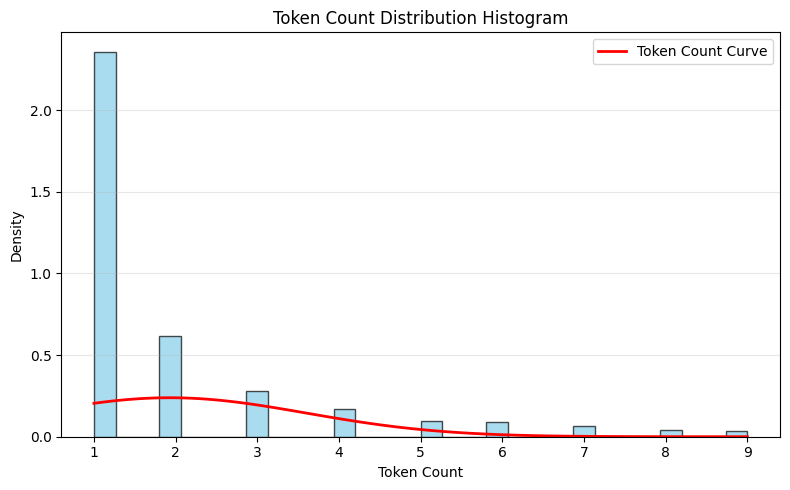

In [9]:
#tmp_token_cnt = list([v for _, v in token2cnt.items()])
tmp_token_cnt = list([v for _, v in token2cnt.items() if v < 10])

plt.figure(figsize=(8, 5))  # 设置图像大小
n, bins, patches = plt.hist(
    tmp_token_cnt,  # 数据
    bins=30,  # 分箱数量
    density=True,  # 密度归一化
    alpha=0.7,  # 透明度
    color='skyblue',  # 颜色
    edgecolor='black'  # 边框颜色
)

# 添加标题和标签
plt.title('Token Count Distribution Histogram')
plt.xlabel('Token Count')
plt.ylabel('Density')

# 添加正态分布曲线作为参考
mu, sigma = np.mean(tmp_token_cnt), np.std(tmp_token_cnt)
x = np.linspace(min(bins), max(bins), 100)
plt.plot(x, 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(- (x - mu) ** 2 / (2 * sigma ** 2)), 'r-', lw=2,
         label='Token Count Curve')

plt.legend()  # 显示图例
plt.grid(axis='y', alpha=0.3)  # 添加网格线
plt.tight_layout()  # 自动调整布局
plt.show()

In [10]:
list([(k, v) for k, v in token2cnt.items() if v > 1000])

[('的', 7915),
 ('吗', 1560),
 ('播放', 1729),
 ('给', 1443),
 ('一下', 1756),
 ('我', 4755),
 ('是', 1718),
 ('帮', 1396)]

In [11]:
print(len(token2cnt))
print(len(list([(k, v) for k, v in token2cnt.items() if v == 1])))

11136
6308


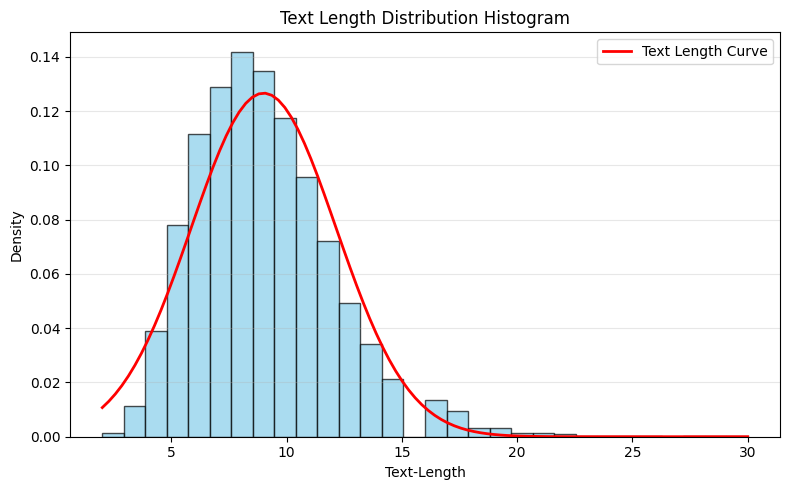

In [12]:
# 可视化看看文本 长度的分布图
plt.figure(figsize=(8, 5))  # 设置图像大小
n, bins, patches = plt.hist(
    text_lens,  # 数据
    bins=30,  # 分箱数量
    density=True,  # 密度归一化
    alpha=0.7,  # 透明度
    color='skyblue',  # 颜色
    edgecolor='black'  # 边框颜色
)

# 添加标题和标签
plt.title('Text Length Distribution Histogram')
plt.xlabel('Text-Length')
plt.ylabel('Density')

# 添加正态分布曲线作为参考
mu, sigma = np.mean(text_lens), np.std(text_lens)
x = np.linspace(min(bins), max(bins), 100)
plt.plot(x, 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(- (x - mu) ** 2 / (2 * sigma ** 2)), 'r-', lw=2,
         label='Text Length Curve')

plt.legend()  # 显示图例
plt.grid(axis='y', alpha=0.3)  # 添加网格线
plt.tight_layout()  # 自动调整布局
plt.show()

In [13]:
# 基于单词的数量构建词典
token2ids = {
    "<PAD>": 0,
    "<UNK>": 1
}
for token, cnt in token2cnt.items():
    if cnt < 3:
        continue  # 一般情况下出现次数太少的单词直接过滤
    token2ids[token] = len(token2ids)
save_json("./output/text_classify/token2ids.json", token2ids)

In [14]:
label2ids = {}
for label, cnt in label2cnt.items():
    label2ids[label] = len(label2ids)
save_json("./output/text_classify/label2ids.json", label2ids)

### 分词器

In [17]:
@dataclass
class TokenizerOutput:
    text: str
    tokens: List[str]
    token_ids: List[int]
    label: Optional[str] = None
    label_id: Optional[int] = 0

In [18]:
class Tokenizer:
    def __init__(self, token2ids: Dict[str, int], label2ids: Dict[str, int], unk_token='<UNK>', pad_token='<PAD>'):
        super().__init__()
        self.token2ids = token2ids
        self.unk_token_id = self.token2ids[unk_token]
        self.pad_token_id = self.token2ids[pad_token]
        self.label2ids = label2ids

    def __call__(self, text: str, label: Optional[str] = None) -> TokenizerOutput:
        # 1. 分词
        tokens = split_text_to_tokens(text)

        # 2. 将每个token转换为token id
        token_ids = [self.token2ids.get(token, self.unk_token_id) for token in tokens]

        # 3. 标签转换
        label_id = None
        if label is not None:
            label_id = self.label2ids[label]

        return TokenizerOutput(text, tokens, token_ids, label, label_id)

In [19]:
token2ids = load_json(r"./output/text_classify/token2ids.json")
label2ids = load_json(r"./output/text_classify/label2ids.json")
tokenizer = Tokenizer(token2ids, label2ids)

tokenizer("怎么从这里回家", "Travel-Query")

TokenizerOutput(text='怎么从这里回家', tokens=['怎么', '从', '这里', '回家'], token_ids=[12, 10, 11, 13], label='Travel-Query', label_id=0)

### Dataset定义及创建

In [21]:
class TextClassifyDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[str], tokenizer: Tokenizer):
        super().__init__()

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __getitem__(self, index):
        # 1. 获取index对应的原始文本和原始标签字符串
        text = self.texts[index]
        label = self.labels[index]

        # 2. 分词 + token2id转换值 + 标签id转换
        tokenizer_output = self.tokenizer(text=text, label=label)

        # 3. 结果返回
        return {
            'text': tokenizer_output.text,
            'tokens': tokenizer_output.tokens,
            'token_ids': torch.tensor(tokenizer_output.token_ids, dtype=torch.int64),
            'token_masks': torch.ones(len(tokenizer_output.token_ids), dtype=torch.float32),
            'label': tokenizer_output.label,
            'label_id': torch.tensor(tokenizer_output.label_id, dtype=torch.int64)
        }

    def __len__(self):
        return len(self.texts)

In [22]:
df = pd.read_csv(r"../datas/text_classify/train.csv", sep="\t", header=None, names=['text', 'label'])
ds = TextClassifyDataset(texts=df.text.values, labels=df.label.values, tokenizer=tokenizer)

In [23]:
ds[10]

{'text': '单曲循环一首催眠的歌吧',
 'tokens': ['单曲', '循环', '一首', '催眠', '的', '歌', '吧'],
 'token_ids': tensor([60, 61, 16,  1,  5, 19, 62]),
 'token_masks': tensor([1., 1., 1., 1., 1., 1., 1.]),
 'label': 'Music-Play',
 'label_id': tensor(1)}

In [24]:
ds[11]

{'text': '你能播放一下曹盾导演的古装悬疑剧呢',
 'tokens': ['你', '能', '播放', '一下', '曹盾', '导演', '的', '古装', '悬疑剧', '呢'],
 'token_ids': tensor([63, 64, 15, 22,  1, 65,  5, 36, 66, 46]),
 'token_masks': tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]),
 'label': 'FilmTele-Play',
 'label_id': tensor(2)}

### 构建DataLoader

In [25]:
def build_collect_fn(pad_token_id):
    def _collect_fn(_batch):
        # 获取当前批次中的最长序列的长度
        max_len = max([len(_item['token_ids']) for _item in _batch])
        # 合并
        _batch_text, _batch_tokens, _batch_token_ids, _batch_token_masks, _batch_label, _batch_label_id = [], [], [], [], [], []
        for _item in _batch:
            _batch_text.append(_item['text'])
            _batch_tokens.append(_item['tokens'])
            _batch_label.append(_item['label'])
            _batch_label_id.append(_item['label_id'])

            _token_ids = _item['token_ids']
            _token_masks = _item['token_masks']
            if len(_token_ids) < max_len:
                _pad_size = max_len - len(_token_ids)
                _token_ids = torch.cat([
                    _token_ids,
                    torch.ones(size=(_pad_size,), dtype=_token_ids.dtype, device=_token_ids.device) * pad_token_id
                ], dim=0)
                _token_masks = torch.cat([
                    _token_masks,
                    torch.zeros(size=(_pad_size,), dtype=_token_masks.dtype, device=_token_masks.device)
                ], dim=0)
            _batch_token_ids.append(_token_ids)
            _batch_token_masks.append(_token_masks)

        return {
            'text': _batch_text,
            'tokens': _batch_tokens,
            'label': _batch_label,
            'label_id': torch.stack(_batch_label_id, dim=0),
            'token_ids': torch.stack(_batch_token_ids, dim=0),
            'token_masks': torch.stack(_batch_token_masks, dim=0)
        }

    return _collect_fn

In [26]:
def build_dataloader(ds: TextClassifyDataset, batch_size, shuffle=False):
    return DataLoader(
        dataset=ds,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=build_collect_fn(pad_token_id=ds.tokenizer.pad_token_id)
    )

In [27]:
dataloader = build_dataloader(ds, batch_size=2, shuffle=True)

In [28]:
for batch in dataloader:
    print(batch)
    break

{'text': ['星期几是美国的大蒜节', '我需要制定个8号上午11点去做双眼皮的行程。'], 'tokens': [['星期', '几是', '美国', '的', '大蒜', '节'], ['我', '需要', '制定', '个', '8', '号', '上午', '11', '点去', '做', '双眼皮', '的', '行程', '。']], 'label': ['Calendar-Query', 'Alarm-Update'], 'label_id': tensor([8, 7]), 'token_ids': tensor([[ 202,  331,  188,    5,    1,  665,    0,    0,    0,    0,    0,    0,
            0,    0],
        [  24,  597, 1219, 1022,  136,    9,  135,  538,  565,  626,    1,    5,
         1138,  117]]), 'token_masks': tensor([[1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])}


### 模型结构创建

In [39]:
class TextClassifyNetwork(nn.Module):
    def __init__(self, vocab_size, num_classes, hidden_size=128):
        super().__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=hidden_size)

        self.token_features = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.ReLU(),
            nn.Linear(hidden_size * 4, hidden_size * 4),
            nn.ReLU(),
            nn.Linear(hidden_size * 4, hidden_size),
            nn.ReLU()
        )

        self.classify = nn.Linear(hidden_size, num_classes, bias=False)

    def forward(self, token_ids, token_masks):
        """
        文本分类模型的前向执行过程
            bs: batch-size 样本数目
            T: 序列长度
        :param token_ids: 输入的样本token id tensor对象，shape形状为: [bs,T]; LongTensor; bs个文本，每个文本有T个token id； PS：由于文本的实际长度不一样，所以可能存在填充
        :param token_masks: 输入的token对应的填充信息，实际token id位置为1，填充位置为0，shape为:[bs,T]
        :return: [bs,num_classes] 针对每个样本输入当前样本属于各个类别的置信度值
        """
        # 1. 将token id转换为token向量 [bs,T] --> [bs,T,e]
        token_embs = self.embedding_layer(token_ids)

        # 2. 进一步提取更高阶的token向量 [bs,T,e] --> [bs,T,e]
        token_embs = self.token_features(token_embs)

        # 3. 将token向量合并成文本向量 [bs,T,e] --> [bs,e]
        # text_embs = torch.mean(token_embs, dim=1)
        text_lens = torch.sum(token_masks, dim=1, keepdim=True)  # [bs,T] --> [bs,1]
        token_embs = token_embs * token_masks[:, :, None]  # [bs,T,e] * [bs,T,1] --> [bs,T,e]
        text_embs = torch.sum(token_embs, dim=1) / (text_lens + 1e-8)

        # 4. 基于文本特征向量进行全连接决策得到预测置信度 [bs,e] --> [bs,num_classes]
        score = self.classify(text_embs)

        return score

In [41]:
net = TextClassifyNetwork(vocab_size=10000, num_classes=13, hidden_size=128)
print(net)

token_ids = torch.tensor([
    [202, 331, 188, 5, 1, 665, 0, 0, 0, 0, 0, 0, 0, 0],  # 第一个文本
    [24, 597, 1219, 1022, 136, 9, 135, 538, 565, 626, 1, 5, 1138, 117]  # 第二个文本
])
token_masks = torch.tensor([
    [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],  # 第一个文本 实际token数目6个，填充token数目为8个
    # [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],  # 第一个文本 实际token数目6个，填充token数目为8个
    [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]  # 第二个文本 14个token均为实际token
])

r = net(token_ids, token_masks)
print(r)

TextClassifyNetwork(
  (embedding_layer): Embedding(10000, 128)
  (token_features): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
  )
  (classify): Linear(in_features=128, out_features=13, bias=False)
)
tensor([[-0.0832, -0.0152, -0.0113, -0.0074,  0.0218, -0.0202, -0.0543, -0.0306,
         -0.0048, -0.0320,  0.0548, -0.0186, -0.0341],
        [-0.0810,  0.0093, -0.0088,  0.0049,  0.0193, -0.0383, -0.0672, -0.0307,
         -0.0111, -0.0212,  0.0444, -0.0083, -0.0230]], grad_fn=<MmBackward0>)


### 组装整个训练结构

In [53]:
class Trainer(object):
    def __init__(self, train_csv_path, val_csv_path, token2ids_path, label2ids_path, model_output_dir, total_epoch=100,
                 batch_size=8, hidden_size=128, lr=0.01):
        super().__init__()

        self.total_epoch = total_epoch
        self.last_model_path = os.path.join(model_output_dir, "last.pkl")
        os.makedirs(os.path.dirname(self.last_model_path), exist_ok=True)

        # 1. 分词器的构建
        self.token2ids = load_json(token2ids_path)
        self.label2ids = load_json(label2ids_path)
        self.tokenizer = Tokenizer(self.token2ids, self.label2ids)

        # 2. 训练数据构造
        train_df = pd.read_csv(train_csv_path, sep="\t", header=None, names=['text', 'label'])
        train_ds = TextClassifyDataset(
            texts=train_df.text.values,
            labels=train_df.label.values,
            tokenizer=self.tokenizer
        )
        self.train_dataloader = build_dataloader(
            train_ds, batch_size=batch_size, shuffle=True
        )

        # 3. 验证数据的加载
        val_df = pd.read_csv(val_csv_path, sep="\t", header=None, names=['text', 'label'])
        val_ds = TextClassifyDataset(
            texts=val_df.text.values,
            labels=val_df.label.values,
            tokenizer=self.tokenizer
        )
        self.test_dataloader = build_dataloader(
            val_ds, batch_size=batch_size, shuffle=False
        )

        self.net = TextClassifyNetwork(
            vocab_size=len(self.token2ids),
            num_classes=len(self.label2ids),
            hidden_size=hidden_size
        )
        # 损失函数创建
        self.loss_fn = nn.CrossEntropyLoss()
        # 优化器创建
        self.opt = optim.SGD(params=net.parameters(), lr=lr)

    def training(self):
        for epoch in range(self.total_epoch):
            # 训练
            self.net.train()  # 将net模块内部的对应的属性进行标记 --> 因为某些模块在训练和推理的时候采用的是不同逻辑
            train_bar = tqdm(enumerate(self.train_dataloader))
            for batch_idx, batch in train_bar:
                # 获取当前批次的数据x + y
                token_ids = batch['token_ids']
                token_masks = batch['token_masks']

                # 前向过程
                score = self.net(token_ids, token_masks)  # [bs,num_classes]
                loss = self.loss_fn(score, batch['label_id'])

                # 反向过程
                self.opt.zero_grad()  # 重置当前优化器对应的所有参数的梯度为0
                loss.backward()  # 计算和当前损失相同的所有参数的梯度值
                self.opt.step()  # 参数更新

                # print(f"Train Epoch {epoch}/{self.total_epoch} Batch {batch_idx} Loss:{loss.item():.3f}")
                train_bar.set_description(
                    f"Train Epoch {epoch}/{self.total_epoch} Batch {batch_idx} Loss:{loss.item():.3f}")

            # 评估
            self.net.eval()
            with torch.no_grad():
                test_bar = tqdm(enumerate(self.test_dataloader))
                for batch_idx, batch in test_bar:
                    # 获取当前批次的数据x + y
                    token_ids = batch['token_ids']
                    token_masks = batch['token_masks']
                    batch_y_test = batch['label_id']

                    # 前向过程
                    score = self.net(token_ids, token_masks)  # [bs,num_classes]
                    loss = self.loss_fn(score, batch_y_test)

                    # 效果评估
                    pred_idx = torch.argmax(score, dim=1)  # 获取预测的类别id
                    acc = metrics.accuracy_score(batch_y_test.cpu().numpy(), pred_idx.cpu().numpy())

                    _msg = f"Test Epoch {epoch}/{self.total_epoch} Batch {batch_idx} Batch-number:{token_ids.shape[0]} Loss:{loss.item():.3f} Accuracy:{acc:.3f}"
                    # print(_msg)
                    test_bar.set_description(_msg)

            # 模型持久化
            ## torch.save 和joblib.dump类似，底层采用pickle进行二进制的数据存储
            obj = {
                'net_param': self.net.state_dict(),  # 模型网络对应的所有参数
                'epoch': epoch,
                'date': datetime.now()
            }
            torch.save(obj, self.last_model_path)

In [63]:
trainer = Trainer(
    train_csv_path=r"../datas/text_classify/train0.csv",
    val_csv_path=r"../datas/text_classify/val0.csv",
    token2ids_path="./output/text_classify/token2ids.json",
    label2ids_path="./output/text_classify/label2ids.json",
    model_output_dir="./output/text_classify/models",
    total_epoch=5, batch_size=8, hidden_size=128, lr=0.01
)

In [64]:
trainer.training()

Train Epoch 0/5 Batch 1361 Loss:2.500: : 1362it [00:10, 125.56it/s]
Test Epoch 0/5 Batch 151 Batch-number:2 Loss:2.499 Accuracy:0.000: : 152it [00:00, 202.73it/s]
Train Epoch 1/5 Batch 1361 Loss:2.477: : 1362it [00:11, 121.40it/s]
Test Epoch 1/5 Batch 151 Batch-number:2 Loss:2.499 Accuracy:0.000: : 152it [00:00, 198.82it/s]
Train Epoch 2/5 Batch 1361 Loss:2.473: : 1362it [00:11, 122.33it/s]
Test Epoch 2/5 Batch 151 Batch-number:2 Loss:2.499 Accuracy:0.000: : 152it [00:00, 191.33it/s]
Train Epoch 3/5 Batch 1361 Loss:2.475: : 1362it [00:11, 122.67it/s]
Test Epoch 3/5 Batch 151 Batch-number:2 Loss:2.499 Accuracy:0.000: : 152it [00:00, 195.26it/s]
Train Epoch 4/5 Batch 1361 Loss:2.505: : 1362it [00:11, 123.74it/s]
Test Epoch 4/5 Batch 151 Batch-number:2 Loss:2.499 Accuracy:0.000: : 152it [00:00, 195.74it/s]


### 模型推理应用

In [74]:
token2ids = load_json("./output/text_classify/token2ids.json")
label2ids = load_json("./output/text_classify/label2ids.json")
id2labels = {_id: _label for _label, _id in label2ids.items()}
tokenizer = Tokenizer(token2ids, label2ids)

net = TextClassifyNetwork(
    vocab_size=len(token2ids),
    num_classes=len(label2ids),
    hidden_size=128
)
# print(net)
ckpt = torch.load("./output/text_classify/models/last.pkl", map_location='cpu')
net.load_state_dict(ckpt['net_param'])
net.eval()

TextClassifyNetwork(
  (embedding_layer): Embedding(3184, 128)
  (token_features): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
  )
  (classify): Linear(in_features=128, out_features=12, bias=False)
)

In [76]:
text = "从上海怎么去北京"
text = "房间温度太热了，帮忙打开窗户"

token_result = tokenizer(text)
token_ids = torch.tensor([token_result.token_ids], dtype=torch.int64)
token_masks = torch.ones_like(token_ids, dtype=torch.float32)

with torch.no_grad():
    score = net(token_ids, token_masks)
prob = torch.softmax(score, dim=-1)
result = torch.topk(prob, k=3)
print(result)
topk_probs = result.values.cpu().numpy()[0]
topk_indices = result.indices.cpu().numpy()[0]
topk_class_names = [id2labels[_id] for _id in topk_indices]
print(topk_probs, "\n", topk_indices, "\n", topk_class_names)

torch.return_types.topk(
values=tensor([[0.0869, 0.0850, 0.0849]]),
indices=tensor([[ 0,  2, 11]]))
[0.08685306 0.08500262 0.08485613] 
 [ 0  2 11] 
 ['Travel-Query', 'FilmTele-Play', 'Other']
